In [34]:
# !pip install google-api-python-client

In [5]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
import os
import sys
import time
import pandas as pd
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
from dotenv import load_dotenv
from tqdm import tqdm
from datetime import datetime

sys.path.append(os.path.abspath('..'))

# Load API key from .env file (NEVER hardcode it)
load_dotenv()
API_KEY = os.getenv("YOUTUBE_API_KEY")

if not API_KEY:
    raise ValueError("YOUTUBE_API_KEY not found. Add it to your .env file.")

print("✅ API Key loaded successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ API Key loaded successfully.
Timestamp: 2026-05-18 14:10:38


In [6]:
# ============================================================
# CELL 2 — YouTube Client Initialisation
# ============================================================
def get_youtube_client(api_key: str):
    """Build and return YouTube Data API v3 client."""
    return build("youtube", "v3", developerKey=api_key)

youtube = get_youtube_client(API_KEY)
print("✅ YouTube API client initialised.")

✅ YouTube API client initialised.


In [19]:
# ============================================================
# CELL 3 — Search Queries Definition
# Data Collection Strategy:
# We use multiple search queries to maximise coverage of the
# fuel price hike discourse on YouTube.
# Time window: 2023-2025 captures recent global fuel price events.
# ============================================================

SEARCH_QUERIES = [
    "fuel price hike 2026",
    "petrol price increase 2026",
    "gas price spike reaction",
    "fuel cost crisis people reaction",
    "petrol price hike australia 2026",
    "oil price surge economy impact",
    "fuel prices too high opinion",
    "why is petrol so expensive 2026",
]

# Published after this date (ISO 8601 format)
PUBLISHED_AFTER = "2023-01-01T00:00:00Z"
MAX_VIDEOS_PER_QUERY = 30   # 50 max per API call
MAX_COMMENTS_PER_VIDEO = 150

print(f"Queries defined: {len(SEARCH_QUERIES)}")
print(f"Max videos per query: {MAX_VIDEOS_PER_QUERY}")
print(f"Max comments per video: {MAX_COMMENTS_PER_VIDEO}")
print(f"Published after: {PUBLISHED_AFTER}")
print(f"\nEstimated quota usage:")
print(f"  Search calls:  {len(SEARCH_QUERIES)} × 100 = {len(SEARCH_QUERIES)*100} units")
print(f"  Videos stats:  ~{len(SEARCH_QUERIES)*MAX_VIDEOS_PER_QUERY // 50} × 1 = ~{len(SEARCH_QUERIES)*MAX_VIDEOS_PER_QUERY // 50} units")
print(f"  Comments:      up to {len(SEARCH_QUERIES)*MAX_VIDEOS_PER_QUERY} × 1 = ~{len(SEARCH_QUERIES)*MAX_VIDEOS_PER_QUERY} units")
print(f"  Total estimate: ~{len(SEARCH_QUERIES)*100 + len(SEARCH_QUERIES)*MAX_VIDEOS_PER_QUERY} / 10,000 daily quota")

Queries defined: 8
Max videos per query: 30
Max comments per video: 150
Published after: 2023-01-01T00:00:00Z

Estimated quota usage:
  Search calls:  8 × 100 = 800 units
  Videos stats:  ~4 × 1 = ~4 units
  Comments:      up to 240 × 1 = ~240 units
  Total estimate: ~1040 / 10,000 daily quota


In [20]:
# ============================================================
# CELL 4 — Search Videos Function
# YouTube search.list costs 100 quota units per call.
# Returns video metadata for a given query.
# ============================================================
def search_videos(query: str, max_results: int = 50,
                  published_after: str = None) -> pd.DataFrame:
    """
    Search YouTube for videos matching the query.
    
    Parameters:
        query          : search string
        max_results    : max number of results (≤50 per API call)
        published_after: ISO 8601 date string to filter older content
    
    Returns:
        pd.DataFrame with video metadata
    """
    params = {
        "part":             "snippet",
        "q":                query,
        "type":             "video",
        "maxResults":       min(max_results, 50),
        "relevanceLanguage":"en",
        "order":            "relevance",
        "safeSearch":       "none",
    }
    if published_after:
        params["publishedAfter"] = published_after

    try:
        response = youtube.search().list(**params).execute()
    except HttpError as e:
        print(f"  [ERROR] Search failed for '{query}': {e}")
        return pd.DataFrame()

    records = []
    for item in response.get("items", []):
        snippet = item["snippet"]
        records.append({
            "video_id":      item["id"]["videoId"],
            "title":         snippet.get("title", ""),
            "channel_id":    snippet.get("channelId", ""),
            "channel_title": snippet.get("channelTitle", ""),
            "published_at":  snippet.get("publishedAt", ""),
            "description":   snippet.get("description", ""),
            "thumbnail_url": snippet.get("thumbnails", {})
                                    .get("high", {}).get("url", ""),
            "query_used":    query,
        })
    return pd.DataFrame(records)

In [21]:
# ============================================================
# CELL 5 — Get Video Statistics Function
# videos.list costs 1 quota unit per call (up to 50 IDs).
# ============================================================
def get_video_stats(video_ids: list) -> pd.DataFrame:
    """
    Fetch statistics and additional metadata for a batch of video IDs.
    API allows up to 50 IDs per request (1 quota unit each batch).
    """
    records = []
    for i in range(0, len(video_ids), 50):
        batch = video_ids[i:i+50]
        try:
            response = youtube.videos().list(
                part="statistics,snippet,contentDetails",
                id=",".join(batch)
            ).execute()
        except HttpError as e:
            print(f"  [ERROR] Stats fetch failed: {e}")
            continue

        for item in response.get("items", []):
            stats   = item.get("statistics", {})
            snippet = item.get("snippet", {})
            content = item.get("contentDetails", {})
            records.append({
                "video_id":      item["id"],
                "view_count":    int(stats.get("viewCount", 0)),
                "like_count":    int(stats.get("likeCount", 0)),
                "comment_count": int(stats.get("commentCount", 0)),
                "duration":      content.get("duration", ""),
                "category_id":   snippet.get("categoryId", ""),
                "tags":          "|".join(snippet.get("tags", [])),
                "language":      snippet.get("defaultAudioLanguage", ""),
            })
    return pd.DataFrame(records)

In [22]:
# ============================================================
# CELL 6 — Get Comments Function
# commentThreads.list costs 1 quota unit per call.
# Fetches top-level comments (replies not included by default).
# ============================================================
def get_comments(video_id: str, max_comments: int = 200) -> pd.DataFrame:
    """
    Fetch top-level comments for a video.
    
    Parameters:
        video_id    : YouTube video ID
        max_comments: maximum comments to retrieve
    
    Returns:
        pd.DataFrame with comment text, author, likes, replies count
    
    Note: Some videos have comments disabled — handled via try/except.
    """
    comments = []
    page_token = None

    while len(comments) < max_comments:
        params = {
            "part":       "snippet",
            "videoId":    video_id,
            "maxResults": min(100, max_comments - len(comments)),
            "textFormat": "plainText",
            "order":      "relevance",
        }
        if page_token:
            params["pageToken"] = page_token

        try:
            response = youtube.commentThreads().list(**params).execute()
        except HttpError as e:
            # Comments may be disabled on the video
            if "commentsDisabled" in str(e) or "403" in str(e):
                pass  # Silently skip
            else:
                print(f"  [WARNING] Comment error on {video_id}: {e}")
            break

        for item in response.get("items", []):
            top = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "comment_id":   item["id"],
                "video_id":     video_id,
                "author_id":    top.get("authorChannelId", {}).get("value", "anonymous"),
                "author_name":  top.get("authorDisplayName", ""),
                "text":         top.get("textDisplay", ""),
                "like_count":   int(top.get("likeCount", 0)),
                "reply_count":  int(item["snippet"].get("totalReplyCount", 0)),
                "published_at": top.get("publishedAt", ""),
                "updated_at":   top.get("updatedAt", ""),
            })

        page_token = response.get("nextPageToken")
        if not page_token:
            break

    return pd.DataFrame(comments)

In [23]:
# ============================================================
# CELL 7 — Main Data Collection Loop
# Runs all queries, collects videos + stats + comments.
# Saves after each query to avoid data loss on API errors.
# ============================================================
all_videos_list   = []
all_comments_list = []

os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

for q_idx, query in enumerate(SEARCH_QUERIES):
    print(f"\n{'='*55}")
    print(f"[{q_idx+1}/{len(SEARCH_QUERIES)}] Query: '{query}'")
    print(f"{'='*55}")

    # Step 1: Search for videos
    df_search = search_videos(query,
                              max_results=MAX_VIDEOS_PER_QUERY,
                              published_after=PUBLISHED_AFTER)
    if df_search.empty:
        print("  No results found — skipping.")
        continue
    print(f"  Found {len(df_search)} videos from search.")

    # Step 2: Get video stats
    video_ids = df_search["video_id"].tolist()
    df_stats  = get_video_stats(video_ids)
    df_videos = df_search.merge(df_stats, on="video_id", how="left")
    all_videos_list.append(df_videos)
    print(f"  Stats fetched for {len(df_stats)} videos.")

    # Step 3: Collect comments per video
    query_comments = []
    for vid_id in tqdm(video_ids, desc="  Fetching comments"):
        cdf = get_comments(vid_id, max_comments=MAX_COMMENTS_PER_VIDEO)
        if not cdf.empty:
            query_comments.append(cdf)
        time.sleep(0.3)  # Polite rate limiting

    if query_comments:
        query_cdf = pd.concat(query_comments, ignore_index=True)
        all_comments_list.append(query_cdf)
        print(f"  Comments collected: {len(query_cdf)}")
    else:
        print("  No comments collected for this query.")

    # Auto-save after each query
    time.sleep(1)

print("\n✅ Data collection complete!")


[1/8] Query: 'fuel price hike 2026'
  Found 30 videos from search.
  Stats fetched for 30 videos.


  Fetching comments: 100%|█████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.81it/s]


  Comments collected: 825

[2/8] Query: 'petrol price increase 2026'
  Found 30 videos from search.
  Stats fetched for 30 videos.


  Fetching comments: 100%|█████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.78it/s]


  Comments collected: 1058

[3/8] Query: 'gas price spike reaction'
  Found 30 videos from search.
  Stats fetched for 30 videos.


...

  Comments collected: 474

[7/8] Query: 'fuel prices too high opinion'
  Found 30 videos from search.
  Stats fetched for 30 videos.


  Fetching comments: 100%|█████████████████████████████████████████████████████████████| 30/30 [00:21<00:00,  1.38it/s]


  Comments collected: 2780

[8/8] Query: 'why is petrol so expensive 2026'
  Found 30 videos from search.
  Stats fetched for 30 videos.


  Fetching comments: 100%|█████████████████████████████████████████████████████████████| 30/30 [00:22<00:00,  1.36it/s]


  Comments collected: 2549

✅ Data collection complete!


In [24]:
# ============================================================
# CELL 8 — Consolidate & Save Raw Data
# ============================================================
# Combine all dataframes
videos_df   = pd.concat(all_videos_list,   ignore_index=True).drop_duplicates("video_id")
comments_df = pd.concat(all_comments_list, ignore_index=True).drop_duplicates("comment_id")

print(f"Total unique videos:   {len(videos_df)}")
print(f"Total unique comments: {len(comments_df)}")

# Save full raw datasets
videos_df.to_csv('../data/videos_raw.csv', index=False)
comments_df.to_csv('../data/comments_raw.csv', index=False)
print("\n✅ Raw data saved:")
print("   data/videos_raw.csv")
print("   data/comments_raw.csv")

# Create a representative sample ≤10MB for submission
sample_vids = videos_df.sample(min(300, len(videos_df)), random_state=42)
sample_cmts = comments_df.sample(min(3000, len(comments_df)), random_state=42)
sample_vids.to_csv('../data/sample_videos.csv', index=False)
sample_cmts.to_csv('../data/sample_comments.csv', index=False)
print("   data/sample_videos.csv   (submission sample)")
print("   data/sample_comments.csv (submission sample)")

Total unique videos:   212
Total unique comments: 11716

✅ Raw data saved:
   data/videos_raw.csv
   data/comments_raw.csv
   data/sample_videos.csv   (submission sample)
   data/sample_comments.csv (submission sample)


In [25]:
# ============================================================
# CELL 9 — Dataset Overview & Basic EDA
# ============================================================
import matplotlib.pyplot as plt

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"\n📹 Videos Dataset: {videos_df.shape}")
print(videos_df[["title","channel_title","view_count","like_count",
                  "comment_count","published_at"]].head(5).to_string())

print(f"\n💬 Comments Dataset: {comments_df.shape}")
print(comments_df[["video_id","author_name","text",
                    "like_count","reply_count"]].head(5).to_string())

print("\n📊 Null values — Videos:")
print(videos_df.isnull().sum())
print("\n📊 Null values — Comments:")
print(comments_df.isnull().sum())

DATASET OVERVIEW

📹 Videos Dataset: (212, 15)
                                                                                                  title    channel_title  view_count  like_count  comment_count          published_at
0                Fuel Price Hike Is Here! News Update 15th May 2026  #automobile #indiancars #indiansuv     CarToqVideos        1008           3              1  2026-05-15T14:13:58Z
1   Petrol Price Hike 2026: The Rupee Connection Nobody Is Talking About.  India Economy.  #news #india  The Moody Naari         178           3              0  2026-05-17T15:05:00Z
2  Fuel Price Explosion 2026 The ₹3 Hike is Just the Beginning#viralshorts  #youtubeshorts#shorts #fact  Silent Opinion            6           0              0  2026-05-17T12:30:44Z
3                                                            The Fuel Price Chronology: 2014 to 2026 🇮🇳     Vipin Saroha       41820        5625            148  2026-05-17T14:08:03Z
4                                           

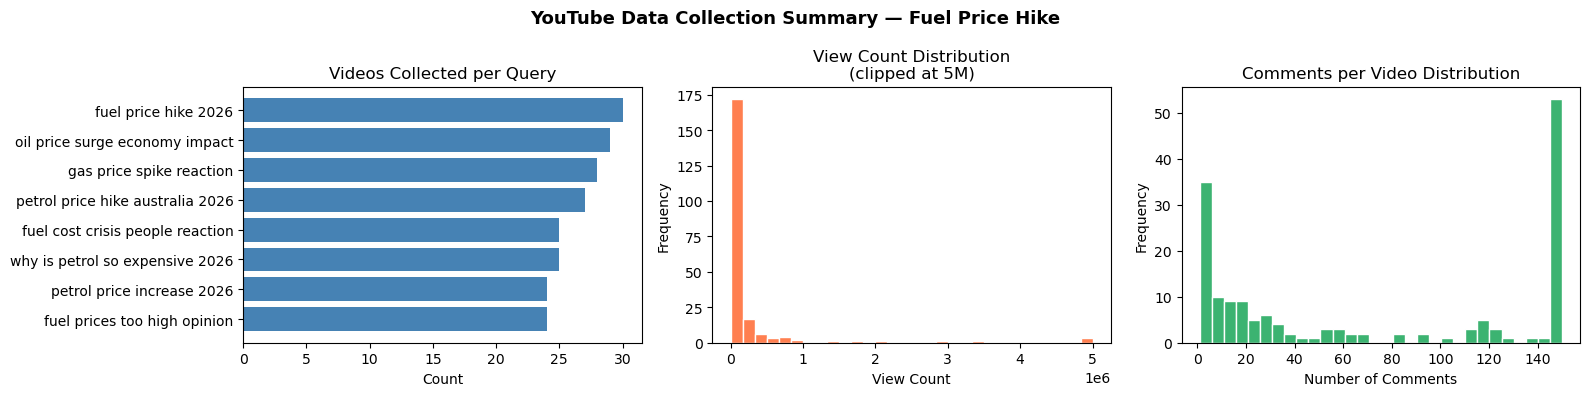

✅ Plot saved: outputs/00_collection_overview.png


In [26]:
# ============================================================
# CELL 10 — Quick Collection Visualisations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Videos per query ---
videos_per_query = videos_df["query_used"].value_counts()
axes[0].barh(videos_per_query.index.str[:35],
             videos_per_query.values, color="steelblue")
axes[0].set_title("Videos Collected per Query")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# --- View count distribution ---
axes[1].hist(videos_df["view_count"].clip(upper=5_000_000),
             bins=30, color="coral", edgecolor="white")
axes[1].set_title("View Count Distribution\n(clipped at 5M)")
axes[1].set_xlabel("View Count")
axes[1].set_ylabel("Frequency")

# --- Comments per video ---
comments_per_video = comments_df["video_id"].value_counts()
axes[2].hist(comments_per_video.values, bins=30,
             color="mediumseagreen", edgecolor="white")
axes[2].set_title("Comments per Video Distribution")
axes[2].set_xlabel("Number of Comments")
axes[2].set_ylabel("Frequency")

plt.suptitle("YouTube Data Collection Summary — Fuel Price Hike",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig('../outputs/00_collection_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved: outputs/00_collection_overview.png")